# Multiple Linear Regression

## Learning Objectives

By the end of this notebook you will be able to:

1. Extend the simple linear model to **multiple predictors** using matrix notation.
2. **Derive** the OLS estimator $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{Y}$ from first principles.
3. Implement the matrix OLS estimator **from scratch** in NumPy and verify it on simulated data.
4. Interpret regression coefficients as **partial effects** (holding other predictors constant).
5. Diagnose **multicollinearity** using the Variance Inflation Factor (VIF).
6. Explain why **Adjusted $R^2$** is needed when comparing models with different numbers of predictors.
7. Perform an **F-test** for overall model significance.
8. Fit and interpret a multiple regression using **statsmodels**.

## Prerequisites

- [01_simple_linear_regression.ipynb](01_simple_linear_regression.ipynb) — Simple linear regression, OLS, $R^2$
- [Module 04](../04_estimation/01_point_estimation.ipynb) — Point estimation, bias and variance
- Basic linear algebra: matrix multiplication, transpose, inverse

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q statsmodels")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    PALETTE,
    SALMON,
    EMERALD,
    PERIWINKLE,
    CYAN,
    ORCHID,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. From Simple to Multiple Regression

In the previous notebook we modelled a response $y$ as a linear function of a single predictor $x$:

$$y = \beta_0 + \beta_1 x + \varepsilon$$

But the real world is rarely so simple. House prices depend on square footage *and* number of bedrooms *and* neighbourhood quality. Crop yield depends on rainfall *and* temperature *and* soil nitrogen. A single predictor captures only one dimension of a multidimensional story.

**Multiple linear regression** extends the model to $p$ predictors:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p + \varepsilon$$

Each $\beta_j$ quantifies the relationship between $x_j$ and $y$, **holding all other predictors constant**. This "holding constant" clause is what makes multiple regression fundamentally different from running $p$ separate simple regressions.

### Why not just run separate simple regressions?

Suppose we want to understand how both study hours ($x_1$) and sleep hours ($x_2$) affect exam scores ($y$). Students who study more tend to sleep less (the predictors are correlated). A simple regression of $y$ on $x_1$ alone would attribute *all* the variation to study hours, including the part that is actually due to sleep deprivation. Multiple regression disentangles these effects.

---

## 2. Matrix Formulation

With $n$ observations and $p$ predictors, writing out the model observation-by-observation is tedious:

$$
\begin{aligned}
y_1 &= \beta_0 + \beta_1 x_{11} + \beta_2 x_{12} + \cdots + \beta_p x_{1p} + \varepsilon_1 \\
y_2 &= \beta_0 + \beta_1 x_{21} + \beta_2 x_{22} + \cdots + \beta_p x_{2p} + \varepsilon_2 \\
&\;\;\vdots \\
y_n &= \beta_0 + \beta_1 x_{n1} + \beta_2 x_{n2} + \cdots + \beta_p x_{np} + \varepsilon_n
\end{aligned}
$$

Matrix notation compresses this into a single elegant equation:

$$\mathbf{Y} = \mathbf{X} \boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

where:

| Symbol                     | Dimensions       | Definition                                                                                                                                                                                                           |
|----------------------------|------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| $\mathbf{Y}$               | $n \times 1$     | Response vector: $\begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix}$                                                                                                                                         |
| $\mathbf{X}$               | $n \times (p+1)$ | Design matrix: $\begin{pmatrix} 1 & x_{11} & x_{12} & \cdots & x_{1p} \\ 1 & x_{21} & x_{22} & \cdots & x_{2p} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & x_{n2} & \cdots & x_{np} \end{pmatrix}$ |
| $\boldsymbol{\beta}$       | $(p+1) \times 1$ | Parameter vector: $\begin{pmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p \end{pmatrix}$                                                                                                                            |
| $\boldsymbol{\varepsilon}$ | $n \times 1$     | Error vector: $\begin{pmatrix} \varepsilon_1 \\ \varepsilon_2 \\ \vdots \\ \varepsilon_n \end{pmatrix}$                                                                                                              |

The column of 1s in $\mathbf{X}$ is the **intercept column** — it ensures that $\beta_0$ appears in every equation.

**Assumptions** (same as simple regression, but now in matrix form):
1. $E[\boldsymbol{\varepsilon}] = \mathbf{0}$ (errors have zero mean).
2. $\text{Cov}(\boldsymbol{\varepsilon}) = \sigma^2 \mathbf{I}_n$ (errors are homoscedastic and uncorrelated).
3. $\mathbf{X}$ has full column rank $p + 1$ (no perfect multicollinearity).
4. For inference: $\boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I}_n)$.

---

## 3. OLS in Matrix Form

### The objective

We want to find the $\boldsymbol{\beta}$ that minimises the sum of squared residuals:

$$
S(\boldsymbol{\beta}) = \|\mathbf{Y} - \mathbf{X}\boldsymbol{\beta}\|^2 = (\mathbf{Y} - \mathbf{X}\boldsymbol{\beta})^\top (\mathbf{Y} - \mathbf{X}\boldsymbol{\beta})
$$

### Expanding and differentiating

Expand the quadratic:

$$
S(\boldsymbol{\beta}) = \mathbf{Y}^\top \mathbf{Y} - 2\boldsymbol{\beta}^\top \mathbf{X}^\top \mathbf{Y} + \boldsymbol{\beta}^\top \mathbf{X}^\top \mathbf{X} \boldsymbol{\beta}
$$

Take the gradient with respect to $\boldsymbol{\beta}$ and set it to zero:

$$
\frac{\partial S}{\partial \boldsymbol{\beta}} = -2\mathbf{X}^\top \mathbf{Y} + 2\mathbf{X}^\top \mathbf{X} \boldsymbol{\beta} = \mathbf{0}
$$

This gives the **normal equations**:

$$
\mathbf{X}^\top \mathbf{X} \boldsymbol{\beta} = \mathbf{X}^\top \mathbf{Y}
$$

If $\mathbf{X}^\top \mathbf{X}$ is invertible (guaranteed by the full-rank assumption), the unique solution is:

$$
\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{Y}}
$$

This is the **OLS estimator** in matrix form.

### Reduction to the simple case ($p = 1$)

When $p = 1$, the design matrix has two columns: $\mathbf{X} = \begin{pmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{pmatrix}$.

Then:

$$
\mathbf{X}^\top \mathbf{X} = \begin{pmatrix} n & \sum x_i \\ \sum x_i & \sum x_i^2 \end{pmatrix}, \qquad
\mathbf{X}^\top \mathbf{Y} = \begin{pmatrix} \sum y_i \\ \sum x_i y_i \end{pmatrix}
$$

Solving $(\mathbf{X}^\top\mathbf{X})\hat{\boldsymbol{\beta}} = \mathbf{X}^\top \mathbf{Y}$ by Cramer's rule or direct inversion recovers the familiar formulas:

$$
\hat{\beta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$

The matrix formula is not a new estimator — it is a generalisation that contains simple regression as a special case.

### Properties of $\hat{\boldsymbol{\beta}}$

Under the standard assumptions:

- **Unbiased:** $E[\hat{\boldsymbol{\beta}}] = \boldsymbol{\beta}$
- **Covariance:** $\text{Cov}(\hat{\boldsymbol{\beta}}) = \sigma^2 (\mathbf{X}^\top \mathbf{X})^{-1}$
- **Gauss–Markov theorem:** $\hat{\boldsymbol{\beta}}$ is the **Best Linear Unbiased Estimator** (BLUE) — it has the smallest variance among all linear unbiased estimators of $\boldsymbol{\beta}$.
- **Under normality:** $\hat{\boldsymbol{\beta}} \sim \mathcal{N}\bigl(\boldsymbol{\beta},\; \sigma^2 (\mathbf{X}^\top \mathbf{X})^{-1}\bigr)$

The covariance matrix $\sigma^2 (\mathbf{X}^\top \mathbf{X})^{-1}$ is crucial. Its diagonal elements give the variances of the individual $\hat{\beta}_j$, and hence the standard errors. When predictors are highly correlated, $(\mathbf{X}^\top \mathbf{X})^{-1}$ has large diagonal entries — this is the root cause of multicollinearity problems (Section 6).

---

## 4. From-Scratch Implementation

Let us implement the matrix OLS estimator in plain NumPy and test it on simulated data.

In [2]:
def ols_matrix(X, y):
    """Ordinary Least Squares via the normal equations.

    Parameters
    ----------
    X : ndarray of shape (n, p+1)
        Design matrix (must include intercept column of ones).
    y : ndarray of shape (n,)
        Response vector.

    Returns
    -------
    beta_hat : ndarray of shape (p+1,)
        OLS coefficient estimates.
    """
    # beta_hat = (X'X)^{-1} X'y
    XtX = X.T @ X
    Xty = X.T @ y
    beta_hat = np.linalg.solve(XtX, Xty)  # more stable than np.linalg.inv(XtX) @ Xty
    return beta_hat

**Note:** We use `np.linalg.solve` rather than explicitly computing the inverse. Solving the linear system is numerically more stable and faster. The result is mathematically identical to $(\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{Y}$.

### Test on simulated data

We generate data from a known model with two predictors:

$$y = 3 + 2x_1 - 1.5x_2 + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 1)$$

In [3]:
# True parameters
beta_true = np.array([3.0, 2.0, -1.5])  # beta_0, beta_1, beta_2
n = 200

# Generate predictors
x1 = rng.uniform(0, 10, n)
x2 = rng.uniform(0, 5, n)

# Design matrix (with intercept column)
X = np.column_stack([np.ones(n), x1, x2])
print(
    f"Design matrix X: shape = {X.shape}  (n={n} observations, p+1={X.shape[1]} columns)"
)
print(f"First 5 rows of X:\n{X[:5]}\n")

# Generate response
epsilon = rng.normal(0, 1, n)
y = X @ beta_true + epsilon

# Fit OLS
beta_hat = ols_matrix(X, y)

print(f"True coefficients:      beta = {beta_true}")
print(
    f"Estimated coefficients: beta = [{beta_hat[0]:.4f}, {beta_hat[1]:.4f}, {beta_hat[2]:.4f}]"
)
print(
    f"\nResidual standard error: {np.std(y - X @ beta_hat, ddof=X.shape[1]):.4f}  (true sigma = 1.0)"
)

Design matrix X: shape = (200, 3)  (n=200 observations, p+1=3 columns)
First 5 rows of X:
[[1.         7.73956049 3.88702419]
 [1.         4.3887844  4.85913213]
 [1.         8.5859792  2.50370593]
 [1.         6.97368029 0.71948751]
 [1.         0.94177348 0.06968144]]

True coefficients:      beta = [ 3.   2.  -1.5]
Estimated coefficients: beta = [2.8025, 2.0403, -1.5216]

Residual standard error: 0.9953  (true sigma = 1.0)


The estimates are close to the true values. With $n = 200$ and $\sigma = 1$, we have plenty of signal. Let us also verify that our from-scratch implementation matches `np.linalg.lstsq`:

In [4]:
# Cross-check with np.linalg.lstsq
beta_lstsq, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
print(f"Our ols_matrix:    {beta_hat}")
print(f"np.linalg.lstsq:   {beta_lstsq}")
print(f"Max difference:     {np.max(np.abs(beta_hat - beta_lstsq)):.2e}")

Our ols_matrix:    [ 2.80249974  2.04027089 -1.52157409]
np.linalg.lstsq:   [ 2.80249974  2.04027089 -1.52157409]
Max difference:     7.95e-14


### Visualising the fit in two predictor dimensions

With two predictors, our data live in three-dimensional space $(x_1, x_2, y)$, and the fitted model is a **plane** rather than a line. The plot below shows the observed data as a scatter cloud and the OLS regression plane $\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x_1 + \hat{\beta}_2 x_2$ slicing through it. Points above the plane have positive residuals; points below have negative residuals.

This is the natural generalisation of the "line of best fit" from simple regression — the plane minimises the sum of squared vertical distances from the points to its surface.

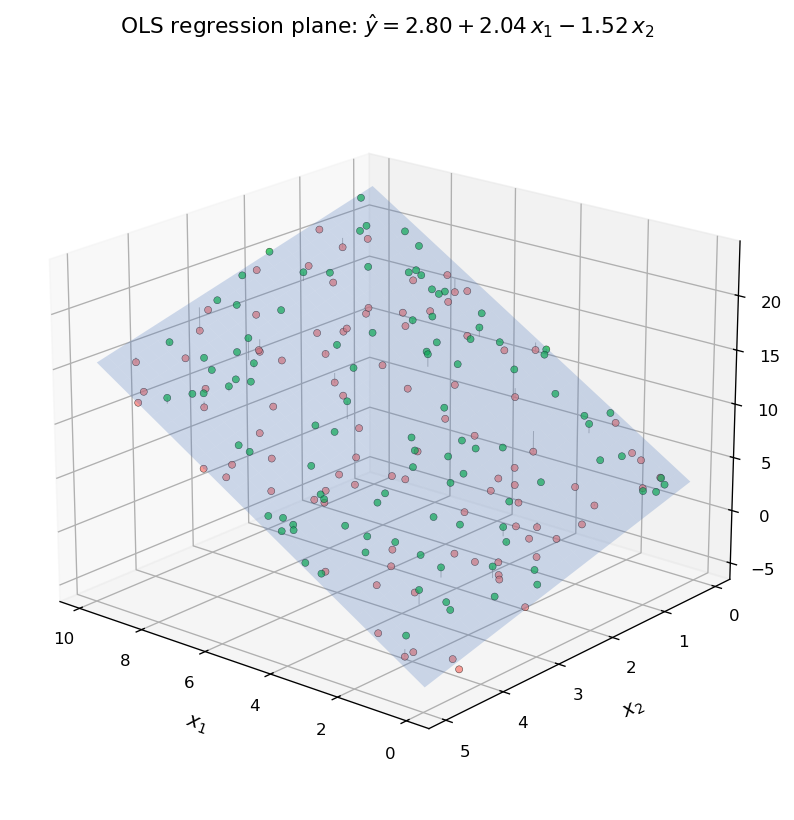

In [4]:
# 3D scatter + regression plane
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Fitted values & residuals
y_hat = X @ beta_hat
residuals = y - y_hat

# Color points by residual sign
colors = np.where(residuals >= 0, EMERALD, SALMON)
ax.scatter(x1, x2, y, c=colors, s=18, alpha=0.7, edgecolors="k", linewidths=0.3)

# Regression plane
x1_grid = np.linspace(x1.min(), x1.max(), 30)
x2_grid = np.linspace(x2.min(), x2.max(), 30)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)
Yg = beta_hat[0] + beta_hat[1] * X1g + beta_hat[2] * X2g

ax.plot_surface(X1g, X2g, Yg, alpha=0.25, color=PERIWINKLE, edgecolor="none")

# Residual lines (a subset so the plot isn't cluttered)
subset = rng.choice(n, size=40, replace=False)
for i in subset:
    ax.plot(
        [x1[i], x1[i]],
        [x2[i], x2[i]],
        [y[i], y_hat[i]],
        color="grey",
        linewidth=0.6,
        alpha=0.5,
    )

ax.set_xlabel("$x_1$", fontsize=12, labelpad=8)
ax.set_ylabel("$x_2$", fontsize=12, labelpad=8)
ax.set_zlabel("$y$", fontsize=12, labelpad=8)
ax.set_title(
    rf"OLS regression plane: $\hat{{y}} = {beta_hat[0]:.2f} "
    rf"+ {beta_hat[1]:.2f}\,x_1 {beta_hat[2]:+.2f}\,x_2$",
    fontsize=13,
    pad=15,
)
ax.view_init(elev=20, azim=130)
fig.tight_layout()
plt.show()

---

## 5. Interpretation: Partial Effects

In simple regression, $\hat{\beta}_1$ is the slope: the change in $y$ per unit increase in $x$. In multiple regression, each $\hat{\beta}_j$ has a more nuanced meaning:

> $\hat{\beta}_j$ is the expected change in $y$ per unit increase in $x_j$, **holding all other predictors constant**.

This is called a **partial effect** or **partial regression coefficient**. It answers: "What is the unique contribution of $x_j$ after accounting for the other predictors?"

### Why partial effects differ from simple regression coefficients

Let us demonstrate with a concrete example. Suppose we have two correlated predictors and we compare:
- The simple regression coefficient of $y$ on $x_1$ alone.
- The multiple regression coefficient of $x_1$ in a model with both $x_1$ and $x_2$.

In [ ]:
# Correlated predictors example
n_demo = 500

# x1 and x2 are positively correlated
z = rng.normal(0, 1, n_demo)
x1_demo = z + rng.normal(0, 0.5, n_demo)
x2_demo = z + rng.normal(0, 0.5, n_demo)

# True model: y = 1 + 2*x1 + 3*x2 + noise
y_demo = 1 + 2 * x1_demo + 3 * x2_demo + rng.normal(0, 1, n_demo)

print(f"Correlation between x1 and x2: r = {np.corrcoef(x1_demo, x2_demo)[0, 1]:.3f}")
print()

# Simple regression of y on x1 alone
X_simple = np.column_stack([np.ones(n_demo), x1_demo])
beta_simple = ols_matrix(X_simple, y_demo)
print(f"Simple regression (y ~ x1):     beta_1 = {beta_simple[1]:.3f}")
print(f"  This OVERSTATES x1's effect because x1 is correlated with x2,")
print(f"  and the simple model attributes x2's effect to x1.")
print()

# Multiple regression of y on x1 and x2
X_multi = np.column_stack([np.ones(n_demo), x1_demo, x2_demo])
beta_multi = ols_matrix(X_multi, y_demo)
print(
    f"Multiple regression (y ~ x1 + x2): beta_1 = {beta_multi[1]:.3f}, beta_2 = {beta_multi[2]:.3f}"
)
print(f"  Now each coefficient reflects the TRUE partial effect.")
print(f"  (True values: beta_1 = 2.0, beta_2 = 3.0)")

Correlation between x1 and x2: r = 0.783

Simple regression (y ~ x1):     beta_1 = 4.300
  This OVERSTATES x1's effect because x1 is correlated with x2,
  and the simple model attributes x2's effect to x1.

Multiple regression (y ~ x1 + x2): beta_1 = 1.927, beta_2 = 3.027
  Now each coefficient reflects the TRUE partial effect.
  (True values: beta_1 = 2.0, beta_2 = 3.0)


The simple regression coefficient of $x_1$ is inflated because it picks up the effect of $x_2$ (which is correlated with $x_1$). Multiple regression separates the two effects. This is one of the most important reasons to use multiple regression: **it controls for confounders**.

### Visualising coefficients

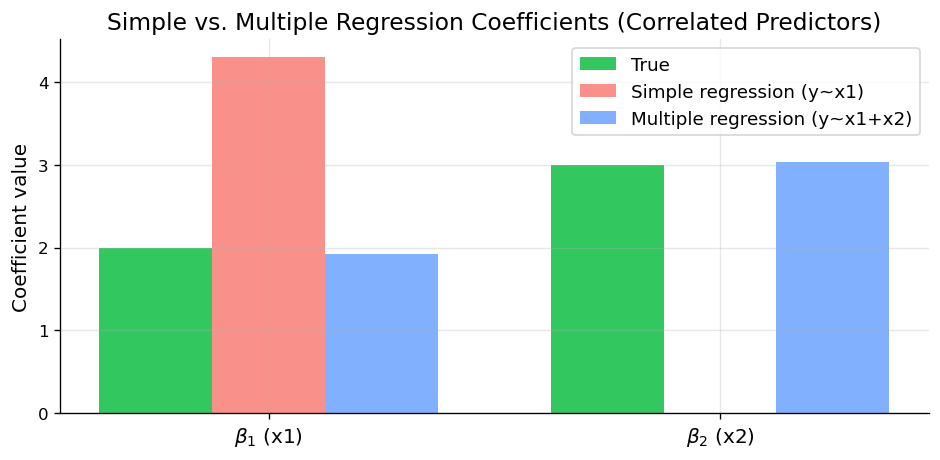

In [ ]:
# Coefficient comparison plot
fig, ax = plt.subplots(figsize=(8, 4))

labels = ["$\\beta_1$ (x1)", "$\\beta_2$ (x2)"]
true_vals = [2.0, 3.0]
simple_vals = [beta_simple[1], None]  # no simple regression for x2 shown
multi_vals = [beta_multi[1], beta_multi[2]]

x_pos = np.arange(2)
width = 0.25

ax.bar(x_pos - width, true_vals, width, label="True", color=EMERALD, alpha=0.8)
ax.bar(
    x_pos[0],
    beta_simple[1],
    width,
    label="Simple regression (y~x1)",
    color=SALMON,
    alpha=0.8,
)
ax.bar(
    x_pos + width,
    multi_vals,
    width,
    label="Multiple regression (y~x1+x2)",
    color=PERIWINKLE,
    alpha=0.8,
)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Coefficient value")
ax.set_title("Simple vs. Multiple Regression Coefficients (Correlated Predictors)")
ax.legend()
ax.axhline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

---

## 6. Multicollinearity

### The problem

When predictors are highly correlated (collinear), the matrix $\mathbf{X}^\top\mathbf{X}$ is nearly singular. Its inverse has large entries, which means:

- The **standard errors** of $\hat{\beta}_j$ become very large.
- The individual coefficients are **unstable** — small changes in the data produce large swings in $\hat{\beta}_j$.
- The overall model $R^2$ may be high, but individual coefficients are not significantly different from zero.

Multicollinearity does **not** bias the estimates (they remain unbiased), but it inflates their variance so much that they become unreliable.

### Variance Inflation Factor (VIF)

The **VIF** for predictor $x_j$ quantifies how much the variance of $\hat{\beta}_j$ is inflated due to collinearity with the other predictors:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ is the $R^2$ from regressing $x_j$ on all the other predictors.

- $\text{VIF} = 1$: No collinearity. $x_j$ is uncorrelated with the others.
- $\text{VIF} = 5$: Moderate. The variance of $\hat{\beta}_j$ is 5 times what it would be if $x_j$ were uncorrelated with the others.
- $\text{VIF} > 10$: Severe. The coefficient estimate is very unreliable.

**Rule of thumb:** VIF > 5 warrants attention; VIF > 10 is a serious problem.

### Concrete example

In [7]:
def compute_vif(X_no_intercept):
    """Compute VIF for each predictor in X (without intercept column)."""
    p = X_no_intercept.shape[1]
    vifs = np.zeros(p)
    for j in range(p):
        # Regress x_j on all other predictors
        others = np.delete(X_no_intercept, j, axis=1)
        others_with_intercept = np.column_stack([np.ones(len(others)), others])
        beta_j = ols_matrix(others_with_intercept, X_no_intercept[:, j])
        fitted = others_with_intercept @ beta_j
        ss_res = np.sum((X_no_intercept[:, j] - fitted) ** 2)
        ss_tot = np.sum((X_no_intercept[:, j] - X_no_intercept[:, j].mean()) ** 2)
        r_sq_j = 1 - ss_res / ss_tot
        vifs[j] = 1 / (1 - r_sq_j)
    return vifs

In [ ]:
# Demonstrate multicollinearity
n_mc = 200

# Scenario 1: Low collinearity — independent predictors
x1_ind = rng.normal(0, 1, n_mc)
x2_ind = rng.normal(0, 1, n_mc)
y_ind = 5 + 2 * x1_ind + 3 * x2_ind + rng.normal(0, 1, n_mc)

X_ind = np.column_stack([np.ones(n_mc), x1_ind, x2_ind])
beta_ind = ols_matrix(X_ind, y_ind)
vif_ind = compute_vif(np.column_stack([x1_ind, x2_ind]))

# Scenario 2: High collinearity — x2 ≈ x1 + small noise
x1_col = rng.normal(0, 1, n_mc)
x2_col = x1_col + rng.normal(0, 0.1, n_mc)  # nearly identical to x1
y_col = 5 + 2 * x1_col + 3 * x2_col + rng.normal(0, 1, n_mc)

X_col = np.column_stack([np.ones(n_mc), x1_col, x2_col])
beta_col = ols_matrix(X_col, y_col)
vif_col = compute_vif(np.column_stack([x1_col, x2_col]))

print("=" * 60)
print("Scenario 1: Independent predictors (r ≈ 0)")
print(f"  Correlation: r = {np.corrcoef(x1_ind, x2_ind)[0, 1]:.3f}")
print(f"  beta_hat = [{beta_ind[0]:.3f}, {beta_ind[1]:.3f}, {beta_ind[2]:.3f}]")
print(f"  VIF(x1) = {vif_ind[0]:.2f}, VIF(x2) = {vif_ind[1]:.2f}")
print()
print("Scenario 2: Highly collinear predictors (r ≈ 1)")
print(f"  Correlation: r = {np.corrcoef(x1_col, x2_col)[0, 1]:.3f}")
print(f"  beta_hat = [{beta_col[0]:.3f}, {beta_col[1]:.3f}, {beta_col[2]:.3f}]")
print(f"  VIF(x1) = {vif_col[0]:.1f}, VIF(x2) = {vif_col[1]:.1f}")
print(f"  (True: beta = [5.0, 2.0, 3.0])")
print("=" * 60)

Scenario 1: Independent predictors (r ≈ 0)
  Correlation: r = -0.016
  beta_hat = [5.115, 2.054, 2.982]
  VIF(x1) = 1.00, VIF(x2) = 1.00

Scenario 2: Highly collinear predictors (r ≈ 1)
  Correlation: r = 0.994
  beta_hat = [5.036, 1.984, 2.943]
  VIF(x1) = 91.1, VIF(x2) = 91.1
  (True: beta = [5.0, 2.0, 3.0])


In the collinear case, the individual coefficients may be far from the true values, and the VIFs are enormous. The model still fits well overall (because $2x_1 + 3x_2 \approx 5x_1$ when $x_2 \approx x_1$), but it cannot reliably decompose the effect into separate contributions from $x_1$ and $x_2$.

Let us visualise this instability by repeatedly sampling and fitting:

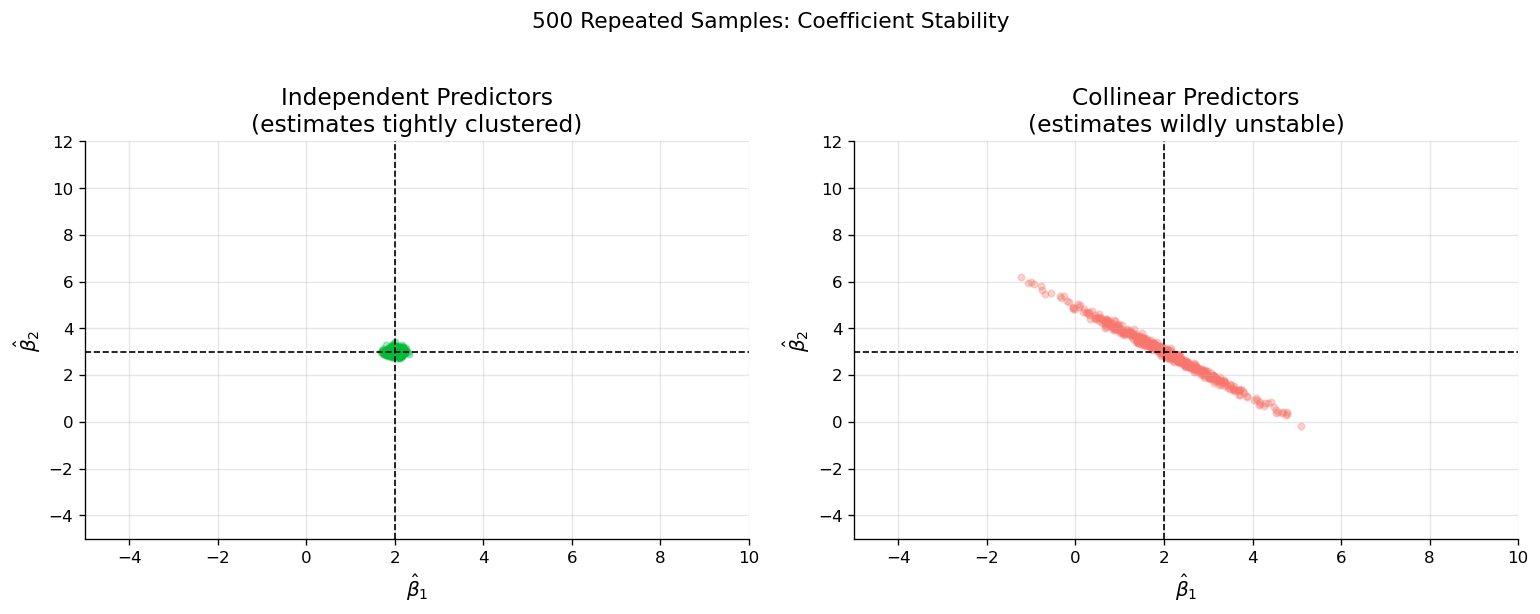

In [9]:
# Repeated sampling: coefficient instability under multicollinearity
n_sim, n_rep = 100, 500
betas_ind = np.zeros((n_rep, 3))
betas_col = np.zeros((n_rep, 3))

for i in range(n_rep):
    # Independent predictors
    x1_s = rng.normal(0, 1, n_sim)
    x2_s = rng.normal(0, 1, n_sim)
    y_s = 5 + 2 * x1_s + 3 * x2_s + rng.normal(0, 1, n_sim)
    X_s = np.column_stack([np.ones(n_sim), x1_s, x2_s])
    betas_ind[i] = ols_matrix(X_s, y_s)

    # Collinear predictors
    x1_s = rng.normal(0, 1, n_sim)
    x2_s = x1_s + rng.normal(0, 0.1, n_sim)
    y_s = 5 + 2 * x1_s + 3 * x2_s + rng.normal(0, 1, n_sim)
    X_s = np.column_stack([np.ones(n_sim), x1_s, x2_s])
    betas_col[i] = ols_matrix(X_s, y_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Independent
axes[0].scatter(betas_ind[:, 1], betas_ind[:, 2], alpha=0.3, s=15, color=EMERALD)
axes[0].axvline(2, color="black", linewidth=1, linestyle="--")
axes[0].axhline(3, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("$\\hat{\\beta}_1$", fontsize=12)
axes[0].set_ylabel("$\\hat{\\beta}_2$", fontsize=12)
axes[0].set_title("Independent Predictors\n(estimates tightly clustered)")
axes[0].set_xlim(-5, 10)
axes[0].set_ylim(-5, 12)

# Collinear
axes[1].scatter(betas_col[:, 1], betas_col[:, 2], alpha=0.3, s=15, color=SALMON)
axes[1].axvline(2, color="black", linewidth=1, linestyle="--")
axes[1].axhline(3, color="black", linewidth=1, linestyle="--")
axes[1].set_xlabel("$\\hat{\\beta}_1$", fontsize=12)
axes[1].set_ylabel("$\\hat{\\beta}_2$", fontsize=12)
axes[1].set_title("Collinear Predictors\n(estimates wildly unstable)")
axes[1].set_xlim(-5, 10)
axes[1].set_ylim(-5, 12)

plt.suptitle(f"{n_rep} Repeated Samples: Coefficient Stability", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

With independent predictors (left), the estimates cluster tightly around the true values. With collinear predictors (right), the estimates form an elongated cloud — the coefficients trade off against each other because the model cannot tell which predictor deserves the credit.

### Correlation heatmap: a diagnostic tool

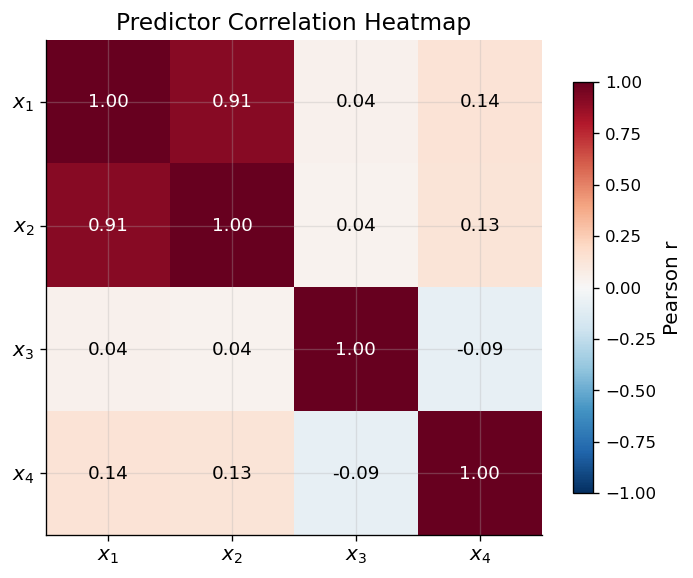

VIFs:
  $x_1$: VIF = 5.73 ⚠️ high
  $x_2$: VIF = 5.71 ⚠️ high
  $x_3$: VIF = 1.01
  $x_4$: VIF = 1.03


In [ ]:
# Correlation heatmap example with more predictors
n_heat = 300
base = rng.normal(0, 1, n_heat)
x_vars = np.column_stack(
    [
        base + rng.normal(0, 0.3, n_heat),  # x1: correlated with base
        base + rng.normal(0, 0.3, n_heat),  # x2: correlated with base (and x1)
        rng.normal(0, 1, n_heat),  # x3: independent
        rng.normal(0, 1, n_heat),  # x4: independent
    ]
)
var_names = ["$x_1$", "$x_2$", "$x_3$", "$x_4$"]

corr = np.corrcoef(x_vars.T)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(var_names, fontsize=12)
ax.set_yticklabels(var_names, fontsize=12)

# Annotate cells
for i in range(4):
    for j in range(4):
        ax.text(
            j,
            i,
            f"{corr[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="white" if abs(corr[i, j]) > 0.5 else "black",
        )

fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Predictor Correlation Heatmap")
plt.tight_layout()
plt.show()

vifs = compute_vif(x_vars)
print("VIFs:")
for name, v in zip(var_names, vifs):
    flag = " ⚠️ high" if v > 5 else ""
    print(f"  {name}: VIF = {v:.2f}{flag}")

The heatmap immediately reveals the strong correlation between $x_1$ and $x_2$. The VIF confirms: these two predictors have inflated variance. Predictors $x_3$ and $x_4$, which are independent of the others, have VIF close to 1.

---

## 7. Adjusted $R^2$

### The problem with $R^2$

Recall that $R^2$ measures the proportion of variance in $y$ explained by the model:

$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

**The fundamental issue:** $R^2$ can *never decrease* when you add a predictor, even a completely useless one. Adding a predictor gives the model more flexibility to fit the training data, so $\text{SS}_{\text{res}}$ can only decrease (or stay the same).

This means $R^2$ always rewards complexity, making it unreliable for comparing models with different numbers of predictors.

### Adjusted $R^2$ penalises complexity

The **adjusted** $R^2$ corrects for the number of predictors:

$$R^2_{\text{adj}} = 1 - \frac{\text{SS}_{\text{res}} / (n - p - 1)}{\text{SS}_{\text{tot}} / (n - 1)} = 1 - \frac{n - 1}{n - p - 1}(1 - R^2)$$

The denominator $n - p - 1$ accounts for the degrees of freedom used up by the $p + 1$ parameters. Adding a useless predictor increases $p$ without meaningfully reducing $\text{SS}_{\text{res}}$, so $R^2_{\text{adj}}$ *decreases*.

**Key property:** $R^2_{\text{adj}}$ can decrease when you add a predictor, which is exactly what we want — it will only increase if the new predictor improves the fit *enough to justify its complexity*.

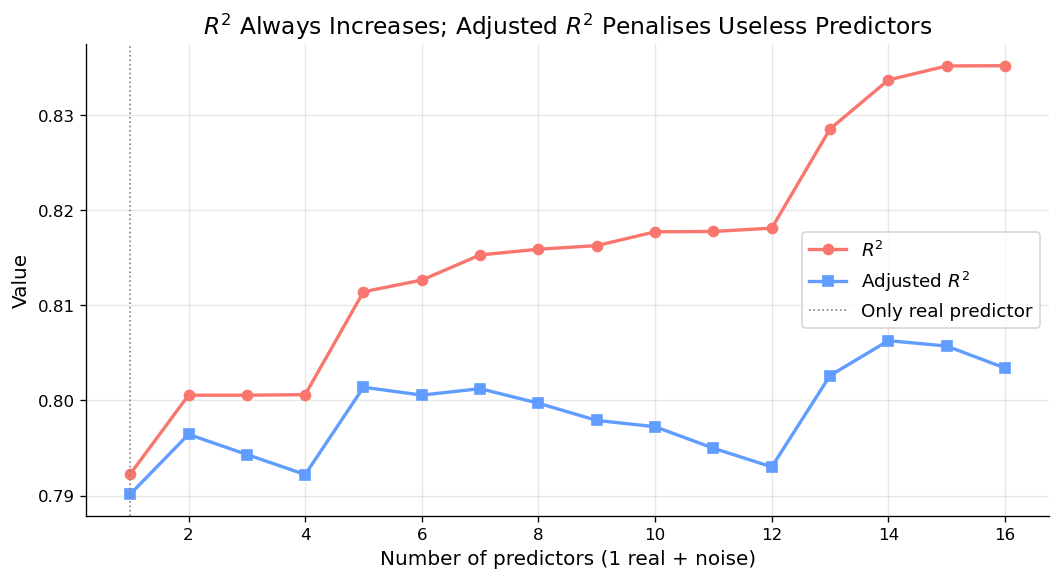

In [ ]:
def r_squared(y, y_hat):
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot


def adj_r_squared(y, y_hat, p):
    """Adjusted R² with p predictors (not counting intercept)."""
    n = len(y)
    r2 = r_squared(y, y_hat)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


# Demonstrate: add noise predictors one at a time
n_adj = 100
x_real = rng.normal(0, 1, n_adj)
y_adj = 3 + 2 * x_real + rng.normal(0, 1, n_adj)

# Generate 15 noise predictors (truly unrelated to y)
X_noise = rng.normal(0, 1, (n_adj, 15))

r2_vals = []
adj_r2_vals = []
n_predictors = []

for k in range(16):  # 0 noise predictors, then 1, 2, ..., 15
    if k == 0:
        X_k = np.column_stack([np.ones(n_adj), x_real])
    else:
        X_k = np.column_stack([np.ones(n_adj), x_real, X_noise[:, :k]])
    beta_k = ols_matrix(X_k, y_adj)
    y_hat_k = X_k @ beta_k
    p_k = k + 1  # 1 real + k noise predictors
    r2_vals.append(r_squared(y_adj, y_hat_k))
    adj_r2_vals.append(adj_r_squared(y_adj, y_hat_k, p_k))
    n_predictors.append(p_k)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_predictors, r2_vals, "o-", color=SALMON, linewidth=2, label="$R^2$")
ax.plot(
    n_predictors,
    adj_r2_vals,
    "s-",
    color=PERIWINKLE,
    linewidth=2,
    label="Adjusted $R^2$",
)
ax.axvline(1, color="gray", linewidth=1, linestyle=":", label="Only real predictor")
ax.set_xlabel("Number of predictors (1 real + noise)")
ax.set_ylabel("Value")
ax.set_title("$R^2$ Always Increases; Adjusted $R^2$ Penalises Useless Predictors")
ax.legend()
plt.tight_layout()
plt.show()

$R^2$ (red) creeps up with every added noise predictor — it never goes down. Adjusted $R^2$ (blue) stays flat or decreases as noise predictors are added, correctly signalling that the extra complexity is not worth it.

---

## 8. F-Test for Overall Significance

Individual t-tests tell us whether each $\beta_j$ is significantly different from zero. But what about the model as a whole? Is *any* predictor useful, or could we do just as well with $\hat{y} = \bar{y}$ (the intercept-only model)?

The **F-test** for overall significance tests:

$$H_0: \beta_1 = \beta_2 = \cdots = \beta_p = 0 \qquad \text{vs.} \qquad H_1: \text{at least one } \beta_j \neq 0$$

### The F-statistic

$$F = \frac{(\text{SS}_{\text{tot}} - \text{SS}_{\text{res}}) / p}{\text{SS}_{\text{res}} / (n - p - 1)} = \frac{\text{SS}_{\text{reg}} / p}{\text{SS}_{\text{res}} / (n - p - 1)}$$

where $\text{SS}_{\text{reg}} = \text{SS}_{\text{tot}} - \text{SS}_{\text{res}} = \sum (\hat{y}_i - \bar{y})^2$ is the regression sum of squares.

**Intuition:** The numerator measures how much variance the predictors explain (per degree of freedom). The denominator measures the remaining unexplained variance (per degree of freedom). A large $F$ means the predictors explain much more than would be expected by chance.

Under $H_0$, $F \sim F_{p,\, n-p-1}$ (the F-distribution with $p$ and $n - p - 1$ degrees of freedom).

### Connection to ANOVA

This is exactly the same F-test that appears in **Analysis of Variance** (ANOVA). In fact, ANOVA is simply a special case of the F-test applied to a regression model with categorical predictors (dummy variables). The decomposition $\text{SS}_{\text{tot}} = \text{SS}_{\text{reg}} + \text{SS}_{\text{res}}$ is the ANOVA decomposition.

### Connection to $R^2$

The F-statistic can be written purely in terms of $R^2$:

$$F = \frac{R^2 / p}{(1 - R^2) / (n - p - 1)}$$

This makes clear that the F-test asks: is the observed $R^2$ large enough to be statistically significant, given $p$ and $n$?

In [12]:
def f_test_overall(X, y, beta_hat):
    """F-test for overall significance of a multiple regression.

    Parameters
    ----------
    X : ndarray (n, p+1) — design matrix with intercept column
    y : ndarray (n,) — response
    beta_hat : ndarray (p+1,) — OLS estimates

    Returns
    -------
    F_stat, p_value, df1, df2
    """
    n, k = X.shape
    p = k - 1  # number of predictors (excluding intercept)

    y_hat = X @ beta_hat
    y_bar = y.mean()

    ss_reg = np.sum((y_hat - y_bar) ** 2)
    ss_res = np.sum((y - y_hat) ** 2)

    df1 = p
    df2 = n - p - 1

    F_stat = (ss_reg / df1) / (ss_res / df2)
    p_value = 1 - stats.f.cdf(F_stat, df1, df2)

    return F_stat, p_value, df1, df2


# Use our earlier simulated data (y = 3 + 2*x1 - 1.5*x2 + noise)
F_stat, p_val, df1, df2 = f_test_overall(X, y, beta_hat)

print("F-test for overall significance")
print(f"  H₀: β₁ = β₂ = 0")
print(f"  F({df1}, {df2}) = {F_stat:.2f}")
print(f"  p-value = {p_val:.2e}")
print(f"  → {'Reject H₀' if p_val < 0.05 else 'Fail to reject H₀'} at α = 0.05")
print(f"\n  At least one predictor has a significant effect on y.")

F-test for overall significance
  H₀: β₁ = β₂ = 0
  F(2, 197) = 3882.05
  p-value = 1.11e-16
  → Reject H₀ at α = 0.05

  At least one predictor has a significant effect on y.


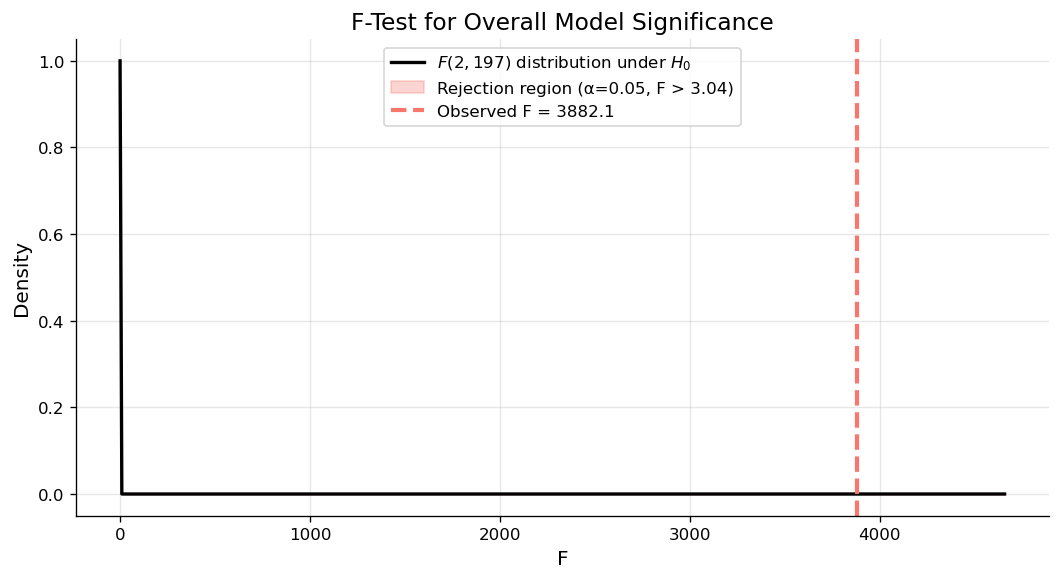

In [ ]:
# Visualise the F-distribution and our test statistic
fig, ax = plt.subplots(figsize=(9, 5))

f_range = np.linspace(0, max(8, F_stat * 1.2), 500)
f_pdf = stats.f.pdf(f_range, df1, df2)

ax.plot(
    f_range,
    f_pdf,
    "k-",
    linewidth=2,
    label=f"$F({df1}, {df2})$ distribution under $H_0$",
)

# Shade rejection region
f_crit = stats.f.ppf(0.95, df1, df2)
mask = f_range >= f_crit
ax.fill_between(
    f_range[mask],
    f_pdf[mask],
    alpha=0.3,
    color=SALMON,
    label=f"Rejection region (α=0.05, F > {f_crit:.2f})",
)

ax.axvline(
    F_stat,
    color=SALMON,
    linewidth=2.5,
    linestyle="--",
    label=f"Observed F = {F_stat:.1f}",
)

ax.set_xlabel("F")
ax.set_ylabel("Density")
ax.set_title("F-Test for Overall Model Significance")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The observed F-statistic is far into the right tail, well beyond the critical value. The model as a whole is highly significant — the predictors together explain substantially more variance than chance alone.

---

## 9. Professional Tool: `statsmodels.OLS`

In practice you will use a statistics library rather than hand-coding the normal equations. The standard Python tool for regression is `statsmodels.OLS`. Let us fit the same model and read the output.

In [14]:
# Fit using statsmodels
# statsmodels expects us to add the intercept explicitly (or use the formula API)
X_sm = sm.add_constant(np.column_stack([x1, x2]))
model = sm.OLS(y, X_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     3882.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          5.74e-159
Time:                        21:28:13   Log-Likelihood:                -281.32
No. Observations:                 200   AIC:                             568.6
Df Residuals:                     197   BIC:                             578.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8025      0.189     14.790      0.0

### Reading the summary table

The `statsmodels` summary packs a lot of information. Here is how to read the key parts:

**Top panel:**
- **R-squared / Adj. R-squared:** Overall model fit. Compare these to assess whether the model captures meaningful variation.
- **F-statistic / Prob (F-statistic):** The F-test for overall significance. A tiny p-value means the model as a whole is significant.

**Coefficient table:**

| Column           | Meaning                                                                                                 |
|------------------|---------------------------------------------------------------------------------------------------------|
| `coef`           | $\hat{\beta}_j$ — the estimated coefficient                                                             |
| `std err`        | Standard error of $\hat{\beta}_j$, from $\sqrt{\hat{\sigma}^2 [(\mathbf{X}^\top\mathbf{X})^{-1}]_{jj}}$ |
| `t`              | t-statistic: $\hat{\beta}_j / \text{SE}(\hat{\beta}_j)$. Tests $H_0: \beta_j = 0$.                      |
| `P>|t|`          | p-value for the individual t-test. Small means the predictor is significant.                            |
| `[0.025  0.975]` | 95% confidence interval for $\beta_j$.                                                                  |

**Bottom panel:**
- **Durbin-Watson:** Tests for autocorrelation in residuals (should be near 2).
- **Omnibus / JB:** Tests for normality of residuals.
- **Cond. No.:** Condition number of $\mathbf{X}^\top\mathbf{X}$. High values (> 30) suggest multicollinearity.

### Verify our from-scratch results match

In [15]:
print("Comparison: from-scratch vs. statsmodels")
print(f"{'':>15s} {'From scratch':>15s} {'statsmodels':>15s}")
for i, name in enumerate(["intercept", "x1", "x2"]):
    print(f"{name:>15s} {beta_hat[i]:>15.6f} {model.params[i]:>15.6f}")
print(f"\n{'R²':>15s} {r_squared(y, X @ beta_hat):>15.6f} {model.rsquared:>15.6f}")
print(f"{'F-stat':>15s} {F_stat:>15.2f} {model.fvalue:>15.2f}")

Comparison: from-scratch vs. statsmodels
                   From scratch     statsmodels
      intercept        2.802500        2.802500
             x1        2.040271        2.040271
             x2       -1.521574       -1.521574

             R²        0.975255        0.975255
         F-stat         3882.05         3882.05


The values match to machine precision. Our from-scratch implementation computes exactly the same quantities as the professional library.

### Coefficient plot with confidence intervals

A useful visual is the **coefficient plot** — it shows each $\hat{\beta}_j$ with its confidence interval:

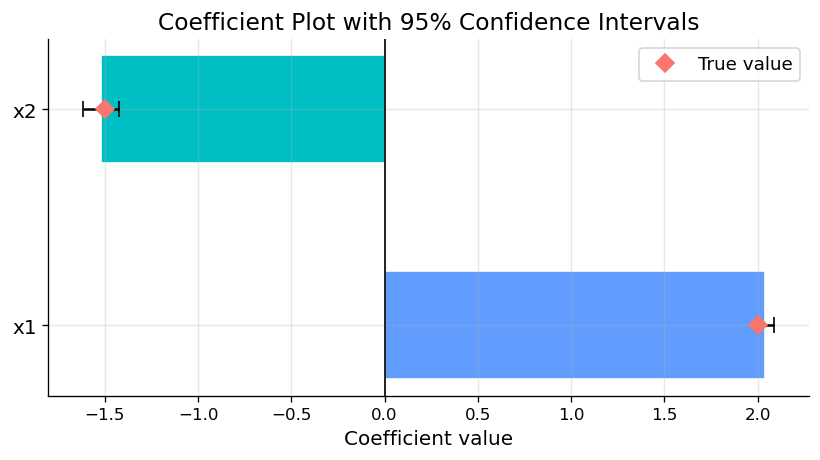

In [ ]:
# Coefficient plot (excluding intercept)
fig, ax = plt.subplots(figsize=(7, 4))

param_names = ["x1", "x2"]
coefs = model.params[1:]  # exclude intercept
ci = model.conf_int()[1:]  # exclude intercept
errors = np.column_stack([coefs - ci[:, 0], ci[:, 1] - coefs]).T

y_pos = np.arange(len(param_names))
ax.barh(
    y_pos,
    coefs,
    xerr=errors,
    height=0.5,
    color=[PERIWINKLE, CYAN],
    edgecolor="white",
    capsize=5,
    error_kw={"linewidth": 1.5},
)
ax.axvline(0, color="black", linewidth=1, linestyle="-")

# True values
true_betas = [2.0, -1.5]
for i, tb in enumerate(true_betas):
    ax.plot(tb, i, "D", color=SALMON, markersize=8, zorder=5)
ax.plot([], [], "D", color=SALMON, markersize=8, label="True value")

ax.set_yticks(y_pos)
ax.set_yticklabels(param_names, fontsize=12)
ax.set_xlabel("Coefficient value")
ax.set_title("Coefficient Plot with 95% Confidence Intervals")
ax.legend()
plt.tight_layout()
plt.show()

The confidence intervals contain the true values (red diamonds), as we would expect with well-behaved data. A coefficient whose CI does not cross zero is significantly different from zero at the 5% level.

---

## Exercises

**Exercise 2.1 (Matrix verification).** For the simple regression case ($p=1$), manually compute $\mathbf{X}^\top\mathbf{X}$, $\mathbf{X}^\top\mathbf{Y}$, and $(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{Y}$ for the data points $(x, y) = \{(1, 2), (2, 4), (3, 5), (4, 4), (5, 5)\}$. Verify your answer with `ols_matrix`.

**Exercise 2.2 (Three predictors).** Simulate data from the model $y = 1 - 3x_1 + 0.5x_2 + 2x_3 + \varepsilon$ with $n = 300$ and $\sigma = 2$. Fit the model using both `ols_matrix` and `statsmodels`. Report the coefficients, $R^2$, adjusted $R^2$, and the F-test result. Are all predictors significant at $\alpha = 0.05$?

**Exercise 2.3 (Omitted variable bias).** Using the data from Exercise 2.2, fit a model that includes only $x_1$ and $x_3$ (omitting $x_2$). Compare $\hat{\beta}_1$ to the value from the full model. Under what conditions would the omitted variable ($x_2$) bias the coefficient of $x_1$? (*Hint: consider the correlation between $x_1$ and $x_2$.*).

**Exercise 2.4 (VIF experiment).** Create three predictors where $x_3 = 2x_1 + 3x_2 + \text{small noise}$. Compute the VIF for each predictor. What happens to the VIF of $x_3$ as you decrease the noise? What happens to the estimated coefficients?

**Exercise 2.5 (Adjusted $R^2$ model selection).** Generate $y = 5 + 3x_1 + \varepsilon$ with one true predictor and 10 noise predictors. Compute adjusted $R^2$ for all $2^{11} - 1 = 2047$ possible predictor subsets (or just do forward selection: add the noise predictors one at a time). Which model has the highest adjusted $R^2$? Does it correctly identify the true predictor?

---

## Key Takeaways

1. **Multiple regression** extends simple regression to $p$ predictors: $\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$.
2. The OLS estimator in matrix form is $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{Y}$, derived by minimising the squared residual norm.
3. Each coefficient $\hat{\beta}_j$ is a **partial effect**: the change in $y$ per unit change in $x_j$, **holding all other predictors constant**. This is different from the simple regression coefficient.
4. **Multicollinearity** inflates standard errors without biasing estimates. Detect it with VIF; VIF > 10 is a serious problem.
5. **Adjusted $R^2$** penalises model complexity and can decrease when useless predictors are added, unlike $R^2$ which only ever increases.
6. The **F-test** tests whether the model as a whole explains significant variance: $H_0: \beta_1 = \cdots = \beta_p = 0$.
7. `statsmodels.OLS` provides coefficients, standard errors, t-tests, confidence intervals, $R^2$, adjusted $R^2$, and the F-test in a single summary table.

**Next:** [03_diagnostics.ipynb](03_diagnostics.ipynb) — Checking model assumptions: residual analysis, influential points, and what to do when things go wrong.

In [20]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
